
---

### 1. Tables Used

| Schema | Table Name | Role / Usage |
|---|---|---|
| **`stg`** | `stg.SAPData` | Main staging source & transformation target |
| **`stg`** | `stg.ProductMaster` | Lookup to set `filtercol` and map products |
| **`stg`** | `stg.MaterialMaster` | Joined with `ProductMaster` for material details |
| **`stg1`** | `stg1.DistCust` | Source staging table for new customer records |
| **`dbo1`** | `dbo1.DimCustomer_OB` | Target dimension table for Customers |
| **`dbo1`** | `dbo1.DimMaterial_OB` | Target dimension table for Materials |
| **`dbo1`** | Executed SP | `[dbo1].[get_subproduct]` (runs dynamic post-transformations) |

---

### 2. Key Transformations Summary

1. **Date & Clean Data Formatting**:
   - **`[Invoice Date]`**: Converted from `DD/MM/YYYY` (code `103`) to `YYYY-MM-DD` (code `23`) and data type altered to `DATE`.
   - **`[PO Date]`**: Handled both ISO (`YYYY-MM-DD`) and UK (`DD/MM/YYYY`) formats safely using `TRY_CONVERT`, then converted to `DATE`.
   - **`[Base Quantity]`**: Stripped commas (`,`) and trailing minus signs (`-`), converting trailing negatives to prefix negatives, then altered data type to `FLOAT`.

2. **Categorization & Derived Columns**:
   - **`Category` Mapping**: Categorized using `[Sales Document Type]`:
     - `ZDS` $\rightarrow$ `Dealer`
     - `ZEB` $\rightarrow$ `Esales`
     - `ZEU` $\rightarrow$ `Project Sale`
     - `ZEX` / `ZEXA` $\rightarrow$ `Export`
     - `ZRE` $\rightarrow$ `Return`
     - `ZSE` $\rightarrow$ `Stock Event`
     - `ZSS` $\rightarrow$ `Solar`
   - **`Category_1` Mapping**: Converts string category names to numeric strings (`Dealer` $\rightarrow$ `'1'`, `Esales` $\rightarrow$ `'2'`, etc.).
   - **`filtercol` Column**: Added dynamically if missing and updated by right-joining `stg.ProductMaster` on material group prefix (`LEFT([Material Group], 4)`).
   - **`[Buyer Code]` Cleaning**: Truncated 10-digit codes to the last 7 digits (`RIGHT([Buyer Code], 7)`).

3. **Dimension Merges / Ingestion**:
   - **`dbo1.DimCustomer_OB`**: Inserts non-existing customer records from `stg1.DistCust`.
   - **`dbo1.DimMaterial_OB`**: Inserts distinct new material codes from `stg.SAPData` combined with metadata from `stg.MaterialMaster` & `stg.ProductMaster`.
   - **External Procedure**: Triggers `EXEC [dbo1].[get_subproduct]`.

4. **Data Normalization & Cleaning**:
   - **State Name Standardization**: Corrected misspellings in `[Consignee State]` (e.g., `'telengana'` $\rightarrow$ `'TELANGANA'`, `'megalaya'` $\rightarrow$ `'MEGHALAYA'`, `'north/south bengal'` $\rightarrow$ `'WEST BENGAL'`).
   - **Quantity Unit Conversion (`Base_Quantity_New`)**:
     - Converted `KG` to `TON` (`/ 1000`).
     - Handled negative quantities based on product class (`AF`, `Pipe`, etc.) using secondary UOM and quantities (`UOM2`, `Quantity2`).

## DBO1 Sheet Pipeline — sap_for_10

This pipeline ingests SAP data from the FTP feed files into the SQL Server staging table `stg.SAPData` and executes a stored procedure to update data formatting.

## Pipeline Details

- **Data Factory**: `JL-ADF-01`
- **Pipeline Hierarchy**: `Cascaded Pipeline > Sheet Pipeline`
- **Pipeline Name**: `sap_for_10`
- **Load Type**: `Full-Load`
- **Lookup Activity Description**: Ingest data from `BW_SAP_DATA_DUMP` into `stg.SAPData`
- **Log Update**: `NO`

## Source

- **Source Type**: `FTP`
- **Source Linked Service**: `SAP_INPUT_LS`
- **IP**: `11.0.6.219`
- **Source File Folder Path**: `BW_SAP_DATA_DUMP/FEED_FILES`
- **Source File Name / Filter Logic**: `dataset().fillenamesap`
- **Source DB Name**: `TestDB`
- **Source Table Name**: `stg.SAPData`
- **Pre Copy Script**: `TRUNCATE TABLE stg.SAPData;`

## Sink

- **Sink Type**: `SQL Server`
- **Sink Linked Service**: `DWH_TestDB`
- **SP Name**: `[dbo1].[sp_update_to_varchar_SAP]`
- **dbo Table Name**: *(None)*

## Column Mapping (Source to Destination)

- **Source File Name / Filter Logic**: `dataset().fillenamesap`
- **Source DB Name**: `TestDB`
- **Source Table Name**: `stg.SAPData`

*(Pending column mapping details — paste the column mapping table when ready)*

## Notes

- Dynamic file name filtering logic using `dataset().fillenamesap`.
- Executes `TRUNCATE TABLE stg.SAPData;` prior to loading new records into staging.
- Executes stored procedure `[dbo1].[sp_update_to_varchar_SAP]` post copy.

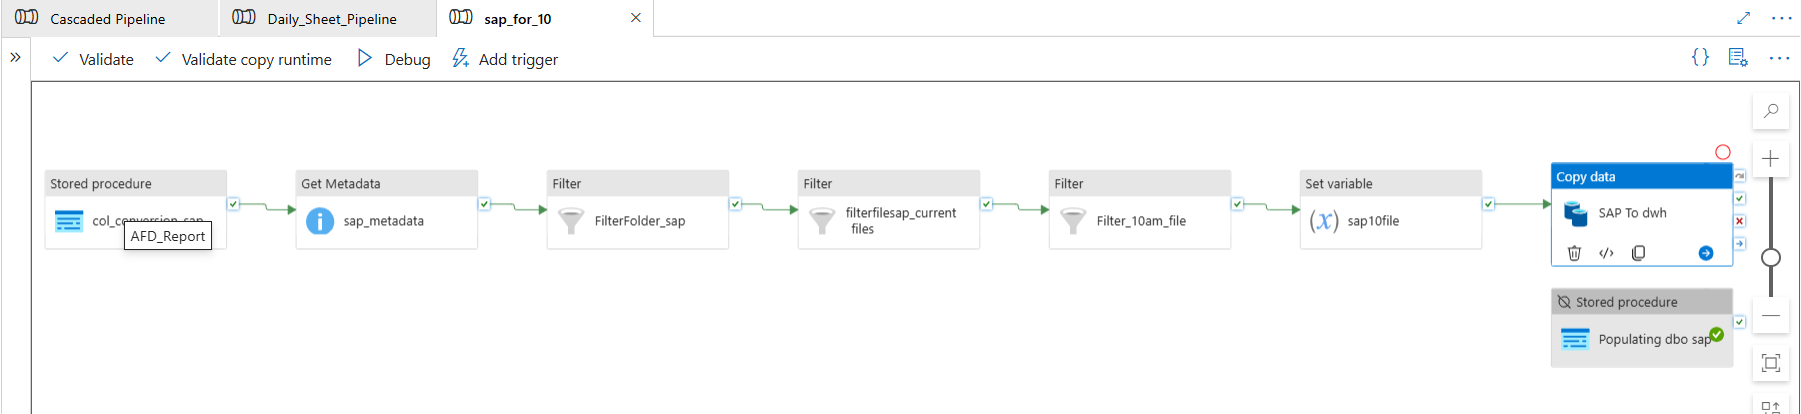